<a href="https://colab.research.google.com/github/yulia3006/ml-basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9612.1_%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D1%81_%D0%B2%D0%B5%D0%BA%D1%82%D0%BE%D1%80%D0%BD%D1%8B%D0%BC%D0%B8_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D0%BC%D0%B8_%D0%B2_GeoPandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Работа с векторными данными в GeoPandas**

Выполняя практическую работу, опирайтесь на теоритический материал, рассматриваемый на занятии:

- Использование NumPy, Pandas и GeoPandas для работы с пространственными данными: https://u.to/rk86Ig
- Ультимативный обзор аналитических инструментов GeoPandas:  https://u.to/s0d3Ig
- Теоретические аспекты и практические примеры получения векторных данных из OpenStreetMap: https://u.to/9SdwIQ

Дополнительно:

- Особенности построения интерактивных карт с помощью библиотеки Leafmap: https://u.to/WvA3Ig

Официальная техническая документацию по используемым библиотекам:

- **NumPy**: https://numpy.org/doc/stable/
- **Pandas**: https://pandas.pydata.org/docs/
- **GeoPandas**: https://geopandas.org/en/stable/docs.html
- **Leafmap**: https://leafmap.org/

In [1]:
%%capture
!pip install geopandas leafmap mapclassify # Устанавливаем библиотеку GeoPandas и необходимые зависимости

In [75]:
from google.colab import output
output.enable_custom_widget_manager()

## **Задание №1. Операции с массивами NumPy и геопространственными координатами**


1. Создайте двумерный массив NumPy, содержащий широту и долготу следующих городов: Токио (35.6895, 139.6917), Нью-Йорк (40.7128, -74.0060), Лондон (51.5074, -0.1278) и Париж (48.8566, 2.3522).


In [52]:
import numpy as np

coords_array = np.array([
    [35.6895, 139.6917],  # Токио
    [40.7128, -74.0060],  # Нью-Йорк
    [51.5074, -0.1278],   # Лондон
    [48.8566, 2.3522]     # Париж
])


2. Преобразуйте значения широты и долготы из градусов в радианы с помощью функции np.radians().


In [53]:
coords_radians = np.radians(coords_array)

print("Координаты в радианах:")
print(coords_radians)

Координаты в радианах:
[[ 6.22899283e-01  2.43808010e+00]
 [ 7.10572408e-01 -1.29164837e+00]
 [ 8.98973719e-01 -2.23053078e-03]
 [ 8.52708531e-01  4.10536347e-02]]




3. Рассчитайте поэлементную разницу между координатами Токио и других городов в радианах.

In [56]:
for idx, city in enumerate(coords_radians):
    if idx > 0:  # пропускаем нулевой индекс, т.к. разница с самим собой = 0
        print(f'Город {idx}: {city - coords_radians[0]}')

Город 1: [ 0.08767312 -3.72972847]
Город 2: [ 0.27607444 -2.44031063]
Город 3: [ 0.22980925 -2.39702647]


## **Задание 2. Операции с DataFrame Pandas и геопространственными данными**


1. Загрузите набор данных о городах мира по следующему URL с помощью Pandas: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv


In [21]:
import pandas as pd
# Pandas поддерживает загрузку данных по прямым ссылкам из сети Интернет
url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"

df = pd.read_csv(url)

2. Отобразите первые 5 строк и проверьте наличие отсутствующих значений.


In [28]:
display(df.head())
print(df.isnull().sum())

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.5833,32.5333,75000
1,2,Fort Portal,UGA,0.6710,30.2750,42670
2,3,Potenza,ITA,40.6420,15.7990,69060
3,4,Campobasso,ITA,41.5630,14.6560,50762
4,5,Aosta,ITA,45.7370,7.3150,34062


id            0
name          0
country       0
latitude      0
longitude     0
population    0
dtype: int64


3. Отфильтруйте набор данных, чтобы включить только города с населением более 1 миллиона человек.


In [29]:
df = df[df['population'] > 1000000]
display(df.head())

,id,name,country,latitude,longitude,population
97,98,Turin,ITA,45.07039,7.66996,1652000
103,104,Lille,FRA,50.64997,3.08001,1044000
123,124,San Bernardino,USA,34.12038,-117.30003,1745000
124,125,Bridgeport,USA,41.17998,-73.19996,1018000
126,127,Manchester,GBR,53.50042,-2.24799,2230000


4. Сгруппируйте города по странам и рассчитайте общую численность населения для каждой страны.


In [61]:
country_population = (
    df.groupby("country", as_index=False)["population"]
    .sum()
    .sort_values("population", ascending=False)
)

country_population

,country,population
18,CHN,203615000
102,USA,134565743
46,IND,134458000
14,BRA,71900406
53,JPN,61636000
...,...,...
28,DNK,1085000
52,JOR,1060000
47,IRL,1059000
60,LBR,1041000




5. Отсортируйте города по населению в порядке убывания и отобразите первые 10 городов.

In [59]:
top_10_cities = df.sort_values('population', ascending=False).head(10)

top_10_cities

,id,name,country,latitude,longitude,population
1239,1240,Tokyo,JPN,35.68502,139.75141,35676000
1224,1225,New York,USA,40.74998,-73.98002,19040000
1230,1231,Mexico City,MEX,19.44244,-99.13099,19028000
1240,1241,Mumbai,IND,19.01699,72.85699,18978000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1148,1149,Delhi,IND,28.66999,77.23000,15926000
1238,1239,Shanghai,CHN,31.21645,121.43650,14987000
1243,1244,Kolkata,IND,22.49497,88.32468,14787000
1175,1176,Dhaka,BGD,23.72306,90.40858,12797394
1217,1218,Buenos Aires,ARG,-34.60250,-58.39753,12795000


## **Задание №3. Создание и обработка GeoDataFrames с помощью GeoPandas**


1. Загрузите набор данных о зданиях Нью-Йорка из файла GeoJSON с помощью GeoPandas: https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson

In [37]:
import geopandas as gpd
import pandas as pd

url = "https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson"

buildings_gdf = gpd.read_file(url)


2. Создайте график контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


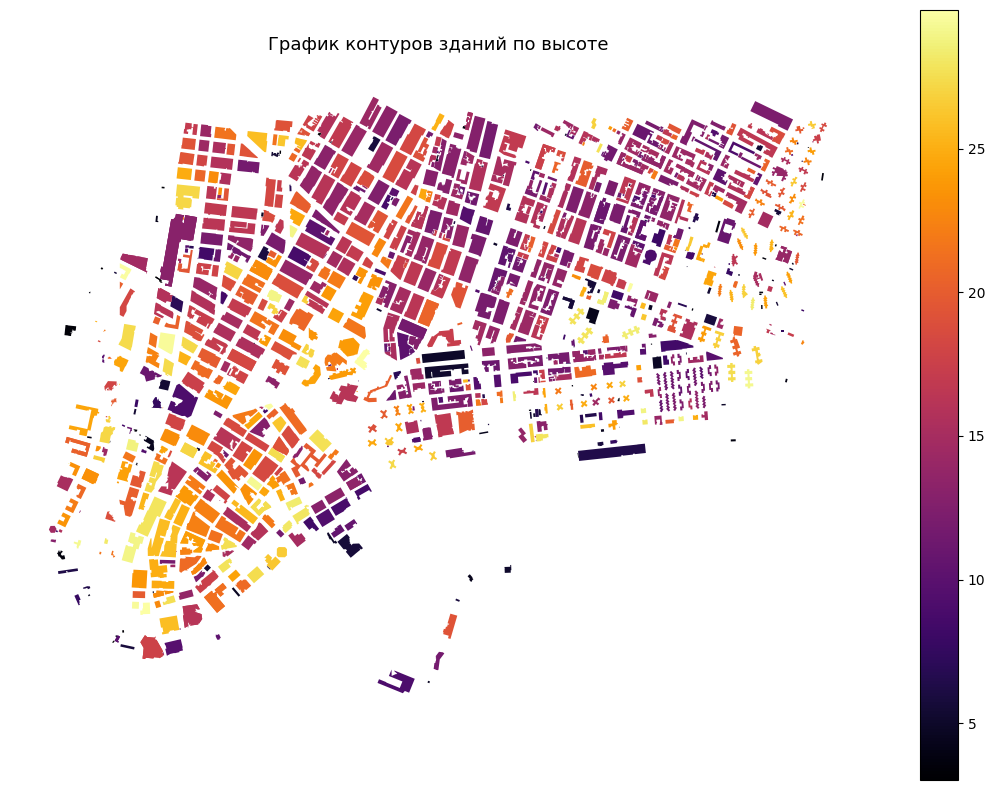

In [43]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 8))

buildings_gdf.plot(
    column='height_MS',
    ax=ax,
    cmap='inferno',
    legend=True,
    linewidth=0.3,
)

ax.set_title('График контуров зданий по высоте', fontsize=13, pad=12)
ax.axis('off')

plt.tight_layout()
plt.show()

3. Создайте интерактивную карту контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


In [50]:
import leafmap

gdf_viz = buildings_gdf[['geometry', 'height_MS']].to_crs("EPSG:4326").dropna(subset=['height_MS'])

m = leafmap.Map(
    center=(40.7128, -74.0060),
    zoom=12,
    basemap='CartoDB.Positron'
)
m.add_data(
    gdf_viz,
    column="height_MS",
    cmap="Blues",
    scheme="EqualInterval",
    legend_title="Высота зданий (м)",
    layer_name="Контур зданий"
)

map

map

In [62]:
from google.colab import output
output.enable_custom_widget_manager()

4. Рассчитайте среднюю высоту зданий (используйте столбец `height_MS`).


In [63]:
avg_building_height = buildings_gdf["height_MS"].mean()

print(f"Средняя высота зданий: {avg_building_height:.2f} м")


Средняя высота зданий: 15.45 м


5. Выберите здания с высотой, превышающей среднюю высоту.


In [64]:
tall_buildings = buildings_gdf[buildings_gdf["height_MS"] > avg_building_height].copy()

print(f" Зданий выше средней высоты ({avg_building_height:.2f} м): {len(tall_buildings)}")

 Зданий выше средней высоты (15.45 м): 524





6. Сохраните GeoDataFrame в новый файл GeoJSON.

In [65]:
export_path = "high_buildings_nyc.geojson"

tall_buildings.to_file(export_path, driver="GeoJSON")

## **Задание №4. Применение NumPy, Pandas и GeoPandas для обработки и анализа пространственных данных**


1. Используйте Pandas для загрузки набора данных о городах мира по следующему URL: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv


In [66]:
import pandas as pd

url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
cities_df = pd.read_csv(url)

cities_df

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.58330,32.53330,75000
1,2,Fort Portal,UGA,0.67100,30.27500,42670
2,3,Potenza,ITA,40.64200,15.79900,69060
3,4,Campobasso,ITA,41.56300,14.65600,50762
4,5,Aosta,ITA,45.73700,7.31500,34062
...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000
1247,1248,Singapore,SGP,1.29303,103.85582,5183700


2. Отфильтруйте набор данных, чтобы включить только города с широтой между -40 и 60 (т.е. города, расположенные в Северном полушарии или вблизи экватора).


In [67]:
selected_cities = cities_df[cities_df["latitude"].between(-40, 60)].copy()

selected_cities.head()

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.5833,32.5333,75000
1,2,Fort Portal,UGA,0.6710,30.2750,42670
2,3,Potenza,ITA,40.6420,15.7990,69060
3,4,Campobasso,ITA,41.5630,14.6560,50762
4,5,Aosta,ITA,45.7370,7.3150,34062


3. Создайте GeoDataFrame из отфильтрованного набора данных, преобразовав широту и долготу в геометрии.


In [69]:
import geopandas as gpd

cities_geo = gpd.GeoDataFrame(
    selected_cities,
    geometry=gpd.points_from_xy(
        selected_cities["longitude"],
        selected_cities["latitude"]
    ),
    crs="EPSG:4326"
)

display(cities_geo.head())

,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.5833,32.5333,75000,POINT (32.5333 0.5833)
1,2,Fort Portal,UGA,0.6710,30.2750,42670,POINT (30.275 0.671)
2,3,Potenza,ITA,40.6420,15.7990,69060,POINT (15.799 40.642)
3,4,Campobasso,ITA,41.5630,14.6560,50762,POINT (14.656 41.563)
4,5,Aosta,ITA,45.7370,7.3150,34062,POINT (7.315 45.737)


4. Перепроецируйте GeoDataFrame в проекцию Меркатора (EPSG:3857).


In [70]:
cities_proj = cities_geo.to_crs("EPSG:3857")

display(cities_proj.head())

,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.5833,32.5333,75000,POINT (3621590.39 64933.781)
1,2,Fort Portal,UGA,0.6710,30.2750,42670,POINT (3370197.584 74697.086)
2,3,Potenza,ITA,40.6420,15.7990,69060,POINT (1758736.635 4959679.293)
3,4,Campobasso,ITA,41.5630,14.6560,50762,POINT (1631498.457 5095742.084)
4,5,Aosta,ITA,45.7370,7.3150,34062,POINT (814302.075 5738302.989)


5. Рассчитайте расстояние (в метрах) между каждым городом и Парижем.


In [72]:
cities_mercator = cities_geo.to_crs("EPSG:3857")

#точка Парижа в той же проекции
paris_point = gpd.GeoSeries(
    gpd.points_from_xy([2.3522], [48.8566]),
    crs="EPSG:4326"
).to_crs("EPSG:3857").iloc[0]

cities_mercator["dist_to_paris"] = cities_mercator.geometry.distance(paris_point)

print(cities_mercator[["name", "country", "dist_to_paris"]].head().to_string())

          name country  dist_to_paris
0        Bombo     UGA   7.039170e+06
1  Fort Portal     UGA   6.913985e+06
2      Potenza     ITA   1.976630e+06
3   Campobasso     ITA   1.791525e+06
4        Aosta     ITA   7.534054e+05




6. Отобразите города на карте мира, раскрасив точки в зависимости от их расстояния до Парижа.



> 💡 **Подсказка:** Вы можете использовать интерактивную карту `leafmap.Map()` и метод m.add_data(), передав в него ваш GeoDataFrame (предварительно возвращенный в систему координат EPSG:4326).

Основные параметры данного метода:


* column — столбец с рассчитанным расстоянием до Парижа (предварительно разделите значение расстояния на 1000, чтобы легенда отображалась в километрах).
* cmap — цветовая палитра (например, "plasma", "viridis" или "YlOrRd").
* k — количество цветовых интервалов (рекомендуется 10–15 для плавности).
* scheme — алгоритм классификации данных:
  * "Quantiles" (Квантили) — делит города на группы с равным количеством точек в каждой. Это создаст максимальный цветовой контраст: даже если города расположены кучно, вы увидите разницу между ними.
   * "EqualInterval" (Равные интервалы) — делит весь диапазон расстояний на равные отрезки в километрах (например, 0-1000 км, 1000-2000 км и т.д.). Это нагляднее показывает реальный масштаб удаленности.



* установите параметр add_legend=True, чтобы на карте появилась шкала соответствия цветов и расстояний.

In [76]:
import geopandas as gpd

paris_proj = gpd.GeoSeries(
    gpd.points_from_xy([2.3522], [48.8566]),
    crs="EPSG:4326"
).to_crs("EPSG:3857").iloc[0]

cities_mercator["distance_to_paris_m"] = cities_mercator.geometry.distance(paris_proj)

print(" Столбцы в таблице:", cities_mercator.columns.tolist())

display(cities_mercator[["name", "country", "distance_to_paris_m"]].head())

 Столбцы в таблице: ['id', 'name', 'country', 'latitude', 'longitude', 'population', 'geometry', 'dist_to_paris', 'distance_to_paris_m']


,name,country,distance_to_paris_m
0,Bombo,UGA,7.039170e+06
1,Fort Portal,UGA,6.913985e+06
2,Potenza,ITA,1.976630e+06
3,Campobasso,ITA,1.791525e+06
4,Aosta,ITA,7.534054e+05
